In [1]:
import pandas as pd
import glob
import numpy as np
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm
import torch
import sys
import os
import matplotlib.pyplot as plt
import importlib

# Add the parent directory to sys.path so src can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import src.utils as utils
import src.utils_semantic_search as uss
importlib.reload(utils)
importlib.reload(uss)

<module 'src.utils_semantic_search' from 'c:\\Users\\karen\\Documents\\HumanidadesDigitales_git\\src\\utils_semantic_search.py'>

In [2]:
#!pip install git+https://github.com/huggingface/transformers -q

In [3]:
import transformers
print(transformers.__version__)

5.0.0.dev0


In [4]:
# Leer archivo parquet
chunks_df = pd.read_parquet(r"..\data\processed\chunks.parquet")

# Ver columnas
print("Columnas disponibles:", chunks_df.columns)

Columnas disponibles: Index(['id_doc', 'autor_doc', 'fecha_doc', 'diario_doc', 'titulo_doc',
       'chunk_id', 'texto_chunk'],
      dtype='object')


In [5]:
corpus = pd. read_excel(r"..\data\processed\corpus_cleaned.xlsx", engine="openpyxl")
corpus.head()

,Diario,Autor,Fecha,Título,Texto,Vínculo,ID,Texto_limpio
0,El Espectador,Gonzalo Hernández,2018-01-01,Fajardo: para nada tibio,"La Coalición Colombia –Partido Alianza Verde, ...",https://web.archive.org/web/20180102104221/htt...,1,"La Coalición Colombia Partido Alianza Verde, P..."
1,El Espectador,Eduardo Barajas Sandoval,2018-01-01,Macedonia de Norte,Las interpretaciones de la historia sirven com...,https://web.archive.org/web/20180102104221/htt...,2,Las interpretaciones de la historia sirven com...
2,El Espectador,Daniel Emilio Rojas Castro,2018-01-01,El nacionalismo según Vargas Llosa,La semana pasada Mario Vargas Llosa publicó un...,https://web.archive.org/web/20180102104221/htt...,3,La semana pasada Mario Vargas Llosa publicó un...
3,El Espectador,Reinaldo Spitaletta,2018-01-01,"Tiempo sagrado, tiempo profano","Pudiera decirse, sin ser una verdad absoluta, ...",https://web.archive.org/web/20180102104221/htt...,4,"Pudiera decirse, sin ser una verdad absoluta, ..."
4,El Espectador,Aura Lucía Mera,2018-01-01,La rebelión de los bueyes,Lo mejor del encierro de Las Ventas fueron los...,https://web.archive.org/web/20180102104221/htt...,5,Lo mejor del encierro de Las Ventas fueron los...


In [6]:
len(chunks_df)

62651

In [7]:
#model = SentenceTransformer('jinaai/jina-embeddings-v2-base-es', trust_remote_code=True)
#model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

In [8]:
# Login into Hugging Face Hub
from huggingface_hub import login, logout

login()

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "google/embeddinggemma-300M"
model = SentenceTransformer(model_id).to(device = device)

print(f"Device: {model.device}")
print(model)
print("Total number of parameters in the model:", sum([p.numel() for _, p in model.named_parameters()]))

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Device: cpu
SentenceTransformer(
  (0): Transformer({'max_seq_length': 2048, 'do_lower_case': False, 'architecture': 'Gemma3TextModel'})
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Dense({'in_features': 768, 'out_features': 3072, 'bias': False, 'activation_function': 'torch.nn.modules.linear.Identity'})
  (3): Dense({'in_features': 3072, 'out_features': 768, 'bias': False, 'activation_function': 'torch.nn.modules.linear.Identity'})
  (4): Normalize()
)
Total number of parameters in the model: 307581696


In [10]:
print(model.max_seq_length)

2048


# Cálculo de similitudes
Fragmentos columnas vs subcategorías de ciencia

In [11]:
# 1. Cargar embeddings de subcategorías
dir_tesauro = r"..\data\external\terminos\Tesauro_Unesco_Ciencia"
subcat_embeddings = uss.cargar_subcategorias(dir_tesauro, model = model)

In [12]:
# 2. Calcular embeddings de chunks y guardarlos
chunk_embeddings = uss.obtener_embeddings_chunks(
    chunks_df,
    model,
    batch_size=128,
    save_path="../data/processed/chunk_embeddings.npy",
    RELOAD=False   # cambiar a True si quieres forzar recálculo
)

Embeddings encontrados en ../data/processed/chunk_embeddings.npy, cargando...
Embeddings cargados con forma: (62651, 768)


In [13]:
# 3. Calcular similitudes con subcategorías
sim_df = uss.calcular_similitudes_chunks(
    chunks_df,
    chunk_embeddings,
    subcat_embeddings
)

In [14]:
sim_df.head(3)

,chunk_id,id_doc,texto_chunk,Ciencias_ambientales_ingenieria,Ciencias_espacio,Ciencias_fisicas,Ciencias_Geografia_oceanografia,Ciencias_medicas,Ciencias_metereologia,Ciencias_naturales,Ciencias_polucion_catastrofes_seguridad,Ciencias_quimicas,Ciencias_tierra,Ciencia_Administracion_ciencia_investigacion,Ciencia_biologia,Ciencia_enfoque_cientifico,Ciencia_hidrologia,Ciencia_matematicas_estadistica,Ciencia_patologia,Ciencia_recursos_naturales
0,0,1,"La Coalición Colombia Partido Alianza Verde, P...",0.411230,0.368818,0.363447,0.354240,0.378154,0.343397,0.387251,0.411649,0.406902,0.392998,0.423331,0.337017,0.352550,0.328395,0.394268,0.393815,0.389038
1,1,1,"al mismo tiempo lo exponen, en ciertas ocasion...",0.331604,0.304309,0.346682,0.315253,0.344347,0.323262,0.344607,0.356739,0.354805,0.318409,0.378231,0.317467,0.368125,0.306375,0.381964,0.337864,0.306510
2,2,1,los acuerdos con las Farc. Anunció que no prom...,0.356805,0.311163,0.303825,0.287517,0.329738,0.290927,0.332603,0.337236,0.314383,0.292858,0.405040,0.291387,0.322885,0.297822,0.338846,0.294842,0.318955


In [15]:
# 3. 1. Calcular similitudes por documento 
sim_doc_df = uss.calcular_similitudes_documentos(chunks_df, chunk_embeddings, subcat_embeddings)
sim_doc_df.head(3)


,id_doc,Ciencias_ambientales_ingenieria,Ciencias_espacio,Ciencias_fisicas,Ciencias_Geografia_oceanografia,Ciencias_medicas,Ciencias_metereologia,Ciencias_naturales,Ciencias_polucion_catastrofes_seguridad,Ciencias_quimicas,Ciencias_tierra,Ciencia_Administracion_ciencia_investigacion,Ciencia_biologia,Ciencia_enfoque_cientifico,Ciencia_hidrologia,Ciencia_matematicas_estadistica,Ciencia_patologia,Ciencia_recursos_naturales
0,1,0.442392,0.398431,0.399799,0.382238,0.423108,0.378949,0.425085,0.442236,0.423654,0.402521,0.476303,0.379507,0.406689,0.367372,0.437932,0.404078,0.407038
1,2,0.424776,0.462440,0.462940,0.468175,0.459761,0.435927,0.484658,0.464754,0.458087,0.460751,0.479642,0.447056,0.426076,0.427546,0.476957,0.460831,0.424228
2,3,0.380767,0.399124,0.403467,0.393175,0.395121,0.362243,0.427816,0.408712,0.408381,0.377452,0.422477,0.371277,0.399744,0.349978,0.421574,0.436097,0.372274


In [16]:
sim_docs_df_merged = pd.merge(corpus[["ID", "Texto_limpio"]],
                              sim_doc_df,
                              left_on="ID", 
                              right_on="id_doc")
sim_docs_df_merged = sim_docs_df_merged.drop(columns=["ID"])
sim_docs_df_merged.head(3)


,Texto_limpio,id_doc,Ciencias_ambientales_ingenieria,Ciencias_espacio,Ciencias_fisicas,Ciencias_Geografia_oceanografia,Ciencias_medicas,Ciencias_metereologia,Ciencias_naturales,Ciencias_polucion_catastrofes_seguridad,Ciencias_quimicas,Ciencias_tierra,Ciencia_Administracion_ciencia_investigacion,Ciencia_biologia,Ciencia_enfoque_cientifico,Ciencia_hidrologia,Ciencia_matematicas_estadistica,Ciencia_patologia,Ciencia_recursos_naturales
0,"La Coalición Colombia Partido Alianza Verde, P...",1,0.442392,0.398431,0.399799,0.382238,0.423108,0.378949,0.425085,0.442236,0.423654,0.402521,0.476303,0.379507,0.406689,0.367372,0.437932,0.404078,0.407038
1,Las interpretaciones de la historia sirven com...,2,0.424776,0.462440,0.462940,0.468175,0.459761,0.435927,0.484658,0.464754,0.458087,0.460751,0.479642,0.447056,0.426076,0.427546,0.476957,0.460831,0.424228
2,La semana pasada Mario Vargas Llosa publicó un...,3,0.380767,0.399124,0.403467,0.393175,0.395121,0.362243,0.427816,0.408712,0.408381,0.377452,0.422477,0.371277,0.399744,0.349978,0.421574,0.436097,0.372274


In [17]:
# GUARDAR SIMILITUDES POR FRAGMENTOS

# Definir ruta de salida
results_dir = r"..\data\results"
os.makedirs(results_dir, exist_ok=True)  # crear carpeta si no existe

output_path = os.path.join(results_dir, "similitudes_chunks.xlsx")

# Guardar el DataFrame en Excel
sim_df.to_excel(output_path, index=False, engine="openpyxl")

print(f"Resultados guardados en {output_path}")

Resultados guardados en ..\data\results\similitudes_chunks.xlsx


In [18]:
# GUARDAR SIMILITUDES POR DOCUMENTO

# Definir ruta de salida
results_dir = r"..\data\results"
os.makedirs(results_dir, exist_ok=True)  # crear carpeta si no existe

output_path = os.path.join(results_dir, "similitudes_docs.xlsx")

# Guardar el DataFrame en Excel
sim_docs_df_merged.to_excel(output_path, index=False, engine="openpyxl")

print(f"Resultados guardados en {output_path}")

Resultados guardados en ..\data\results\similitudes_docs.xlsx


In [19]:
# 4. Asignar categorías con umbral
umbral_elegido = 0.47
resultado = uss.asignar_categorias(sim_df, umbral=umbral_elegido)
resultado.head()

,chunk_id,id_doc,texto_chunk,Ciencias_ambientales_ingenieria,Ciencias_espacio,Ciencias_fisicas,Ciencias_Geografia_oceanografia,Ciencias_medicas,Ciencias_metereologia,Ciencias_naturales,...,Ciencias_quimicas,Ciencias_tierra,Ciencia_Administracion_ciencia_investigacion,Ciencia_biologia,Ciencia_enfoque_cientifico,Ciencia_hidrologia,Ciencia_matematicas_estadistica,Ciencia_patologia,Ciencia_recursos_naturales,categorias_detectadas
0,0,1,"La Coalición Colombia Partido Alianza Verde, P...",0.411230,0.368818,0.363447,0.354240,0.378154,0.343397,0.387251,...,0.406902,0.392998,0.423331,0.337017,0.352550,0.328395,0.394268,0.393815,0.389038,"[(ninguna, 0)]"
1,1,1,"al mismo tiempo lo exponen, en ciertas ocasion...",0.331604,0.304309,0.346682,0.315253,0.344347,0.323262,0.344607,...,0.354805,0.318409,0.378231,0.317467,0.368125,0.306375,0.381964,0.337864,0.306510,"[(ninguna, 0)]"
2,2,1,los acuerdos con las Farc. Anunció que no prom...,0.356805,0.311163,0.303825,0.287517,0.329738,0.290927,0.332603,...,0.314383,0.292858,0.405040,0.291387,0.322885,0.297822,0.338846,0.294842,0.318955,"[(ninguna, 0)]"
3,3,1,moratoria en la explotación tipo fracking. Y f...,0.435032,0.397881,0.372960,0.368983,0.415538,0.357000,0.410173,...,0.393579,0.392092,0.445708,0.370653,0.367256,0.341832,0.404120,0.375238,0.397525,"[(ninguna, 0)]"
4,0,2,Las interpretaciones de la historia sirven com...,0.352643,0.367811,0.375234,0.357391,0.368184,0.347770,0.392265,...,0.365384,0.368177,0.428733,0.353389,0.405911,0.371109,0.412153,0.397781,0.339795,"[(ninguna, 0)]"


In [20]:
resultado['etiqueta_ciencia'] = resultado['categorias_detectadas'].apply(lambda x: 1 if x[0][0] != 'ninguna' else 0)

In [21]:
resultado.head()

,chunk_id,id_doc,texto_chunk,Ciencias_ambientales_ingenieria,Ciencias_espacio,Ciencias_fisicas,Ciencias_Geografia_oceanografia,Ciencias_medicas,Ciencias_metereologia,Ciencias_naturales,...,Ciencias_tierra,Ciencia_Administracion_ciencia_investigacion,Ciencia_biologia,Ciencia_enfoque_cientifico,Ciencia_hidrologia,Ciencia_matematicas_estadistica,Ciencia_patologia,Ciencia_recursos_naturales,categorias_detectadas,etiqueta_ciencia
0,0,1,"La Coalición Colombia Partido Alianza Verde, P...",0.411230,0.368818,0.363447,0.354240,0.378154,0.343397,0.387251,...,0.392998,0.423331,0.337017,0.352550,0.328395,0.394268,0.393815,0.389038,"[(ninguna, 0)]",0
1,1,1,"al mismo tiempo lo exponen, en ciertas ocasion...",0.331604,0.304309,0.346682,0.315253,0.344347,0.323262,0.344607,...,0.318409,0.378231,0.317467,0.368125,0.306375,0.381964,0.337864,0.306510,"[(ninguna, 0)]",0
2,2,1,los acuerdos con las Farc. Anunció que no prom...,0.356805,0.311163,0.303825,0.287517,0.329738,0.290927,0.332603,...,0.292858,0.405040,0.291387,0.322885,0.297822,0.338846,0.294842,0.318955,"[(ninguna, 0)]",0
3,3,1,moratoria en la explotación tipo fracking. Y f...,0.435032,0.397881,0.372960,0.368983,0.415538,0.357000,0.410173,...,0.392092,0.445708,0.370653,0.367256,0.341832,0.404120,0.375238,0.397525,"[(ninguna, 0)]",0
4,0,2,Las interpretaciones de la historia sirven com...,0.352643,0.367811,0.375234,0.357391,0.368184,0.347770,0.392265,...,0.368177,0.428733,0.353389,0.405911,0.371109,0.412153,0.397781,0.339795,"[(ninguna, 0)]",0


In [22]:
resultado_ciencia = resultado[resultado['categorias_detectadas'].apply(lambda x: x[0][0] != 'ninguna')]

In [23]:
# Definir ruta de salida
results_dir = r"..\data\results"
os.makedirs(results_dir, exist_ok=True)  # crear carpeta si no existe

output_path = os.path.join(results_dir, "ciencia_chunks.xlsx")

# Guardar el DataFrame en Excel
resultado_ciencia.to_excel(output_path, index=False, engine="openpyxl")

print(f"Resultados guardados en {output_path}")

Resultados guardados en ..\data\results\ciencia_chunks.xlsx


In [ ]:
# Definir ruta de salida
results_dir = r"..\data\results"
os.makedirs(results_dir, exist_ok=True)  # crear carpeta si no existe

output_path = os.path.join(results_dir, "chunks_etiquetados_binario.xlsx")

# Guardar el DataFrame en Excel
resultado.to_excel(output_path, index=False, engine="openpyxl")

print(f"Resultados guardados en {output_path}")

Resultados guardados en ..\data\results\chunks_etiquetados_binario.xlsx


# Estadísticos y decisión umbral

In [122]:
resultado['categorias_detectadas'].value_counts()

categorias_detectadas
[(ninguna, 0)]                                                                                                               60083
[(Ciencia_Administracion_ciencia_investigacion, 0.5066911578178406)]                                                             1
[(Ciencias_ambientales_ingenieria, 0.5055747628211975), (Ciencias_naturales, 0.5031323432922363)]                                1
[(Ciencias_medicas, 0.5000301599502563), (Ciencia_Administracion_ciencia_investigacion, 0.5287904739379883)]                     1
[(Ciencias_polucion_catastrofes_seguridad, 0.5453317761421204)]                                                                  1
                                                                                                                             ...  
[(Ciencias_espacio, 0.5359177589416504)]                                                                                         1
[(Ciencia_Administracion_ciencia_investigacion, 0.51215189695

In [123]:
# Contar cuantos documentos tienen al menos una categoría asignada
docs_con_categoria = resultado[resultado['categorias_detectadas'].apply(lambda x: x[0][0] != 'ninguna')]['id_doc'].nunique()
docs_con_categoria

1642

In [124]:
# Contar cuantas veces se asigna cada subcategoría
umbral = umbral_elegido
subcat_cols = sim_df.columns[3:20]  # columnas de subcategorías

# Crear DataFrame temporal como float directamente
sim_temp = sim_df[subcat_cols].astype(float)

# Conteo de asignaciones por subcategoría
asignaciones_por_subcat = (sim_temp >= umbral).sum().sort_values(ascending=False)

print("Asignaciones por subcategoría:")
print(asignaciones_por_subcat)

Asignaciones por subcategoría:
Ciencia_Administracion_ciencia_investigacion    1140
Ciencias_polucion_catastrofes_seguridad          749
Ciencias_ambientales_ingenieria                  583
Ciencias_naturales                               239
Ciencia_recursos_naturales                       189
Ciencias_medicas                                 160
Ciencia_patologia                                148
Ciencia_matematicas_estadistica                  111
Ciencia_enfoque_cientifico                        93
Ciencia_hidrologia                                83
Ciencias_espacio                                  47
Ciencias_metereologia                             32
Ciencias_Geografia_oceanografia                   29
Ciencias_fisicas                                  26
Ciencias_tierra                                   25
Ciencias_quimicas                                 23
Ciencia_biologia                                  20
dtype: int64


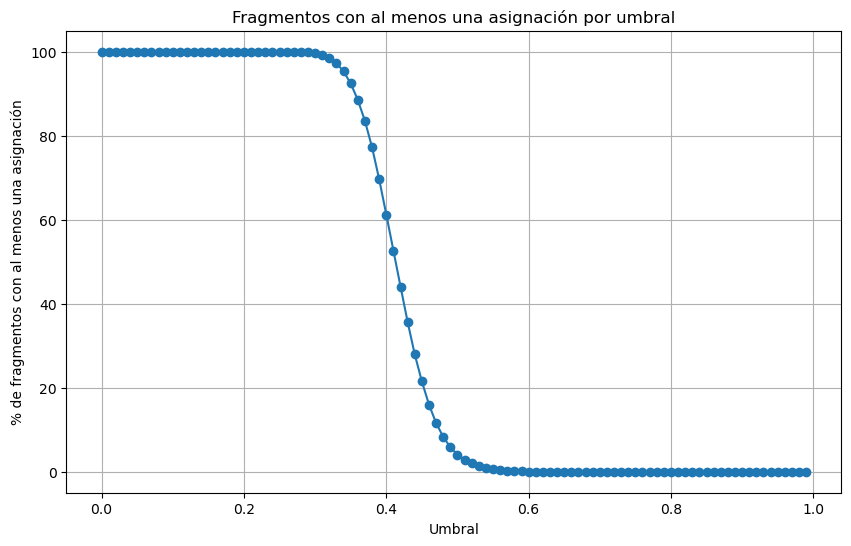

In [125]:
# Graficar chunks con al menos una categoría por umbral
umbrales = np.arange(0, 1, 0.01)
chunks_con_asignacion = []

subcat_cols = resultado.columns[3:20]  # columnas de subcategorías

# Crear DataFrame temporal como float 
sim_temp = resultado[subcat_cols].astype(float)

# Contar chunks con al menos una asignación por umbral
for umbral in umbrales:
    asignados = (sim_temp >= umbral).any(axis=1).sum()  # True si al menos una columna supera el umbral
    chunks_con_asignacion.append(asignados/len(resultado) * 100)  # porcentaje

# Graficar
plt.figure(figsize=(10,6))
plt.plot(umbrales, chunks_con_asignacion, marker='o')
plt.xlabel("Umbral")
plt.ylabel("% de fragmentos con al menos una asignación")
plt.title("Fragmentos con al menos una asignación por umbral")
plt.grid(True)
plt.show()

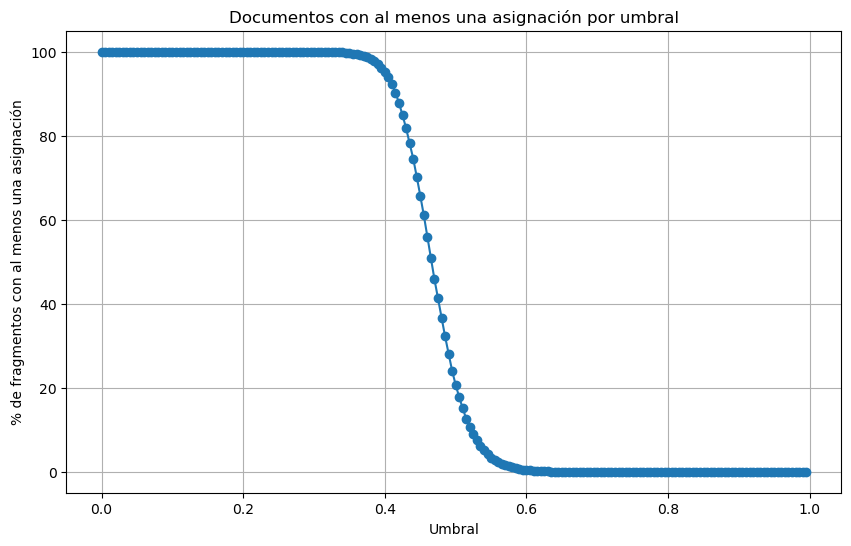

In [81]:
# DOCS con al menos una categoría por umbral
umbrales = np.arange(0, 1, 0.005)
docs_con_asignacion = []
subcat_cols = sim_docs_df_merged.columns[2:19]  # columnas de subcategorías

# Crear DataFrame temporal como float 
sim_temp = sim_docs_df_merged[subcat_cols].astype(float)

# Contar chunks con al menos una asignación por umbral
for umbral in umbrales:
    asignados = (sim_temp >= umbral).any(axis=1).sum()  # True si al menos una columna supera el umbral
    docs_con_asignacion.append(asignados/len(sim_docs_df_merged) * 100)  # porcentaje

# Graficar
plt.figure(figsize=(10,6))
plt.plot(umbrales, docs_con_asignacion, marker='o')
plt.xlabel("Umbral")
plt.ylabel("% de fragmentos con al menos una asignación")
plt.title("Documentos con al menos una asignación por umbral")
plt.grid(True)
plt.show()


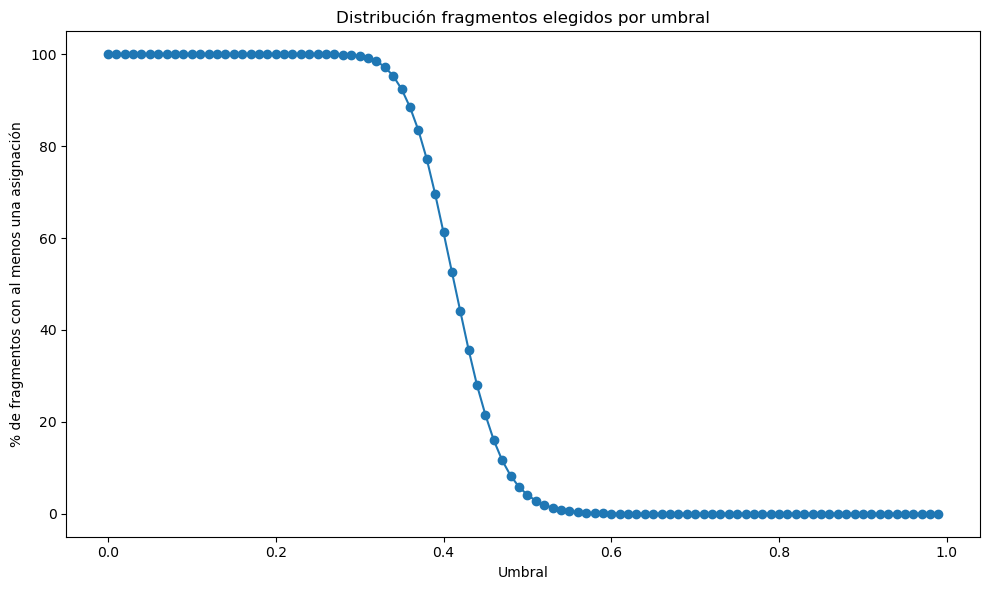

In [126]:
# Guardar en la carpeta figures
plt.figure(figsize=(10,6))
plt.plot(umbrales, chunks_con_asignacion, marker='o')
plt.xlabel("Umbral")
plt.ylabel("% de fragmentos con al menos una asignación")
plt.title("Distribución fragmentos elegidos por umbral")
plt.tight_layout()
#plt.savefig("../reports/ideas PAPERS/figures/dist_umbral.png", dpi=300)
#plt.close()
plt.show()

In [82]:
descriptivos = sim_temp.describe()

In [83]:
# Trasponer los descriptivos
descriptivos.T

,count,mean,std,min,25%,50%,75%,max
Ciencias_ambientales_ingenieria,13676.0,0.409303,0.046582,0.225508,0.379738,0.407436,0.435696,0.625010
Ciencias_espacio,13676.0,0.401269,0.032740,0.247477,0.380315,0.401072,0.421717,0.598691
Ciencias_fisicas,13676.0,0.400112,0.034198,0.230793,0.378122,0.400098,0.422045,0.570140
Ciencias_Geografia_oceanografia,13676.0,0.386136,0.036030,0.224444,0.363616,0.385833,0.408275,0.568285
Ciencias_medicas,13676.0,0.423417,0.036061,0.262596,0.400076,0.423133,0.445891,0.615554
Ciencias_metereologia,13676.0,0.376351,0.035391,0.215150,0.354037,0.375918,0.398029,0.556275
Ciencias_naturales,13676.0,0.433789,0.035941,0.259262,0.410891,0.433085,0.456159,0.594811
Ciencias_polucion_catastrofes_seguridad,13676.0,0.434516,0.046735,0.241285,0.404306,0.435305,0.464613,0.664810
Ciencias_quimicas,13676.0,0.406208,0.032186,0.245425,0.386357,0.407173,0.427284,0.555371
Ciencias_tierra,13676.0,0.389590,0.033858,0.242518,0.368082,0.389059,0.410698,0.577107
